## Setting Up


In [ ]:
import numpy as np
import pandas as pd
import random

from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader

In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import KFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

import random


In [ ]:
# load data

import pandas as pd
data = pd.read_csv('train_set_80_percent.csv')
data = data.drop(columns=["id", "rank", "player", "hard_hit_95mph+"]) # dropping unnecessary columns
data.shape

(1586, 16)

9 missing values. Drop these going forward.

In [ ]:
print(data.isnull().sum())

year                                   0
batted_ball_events                     0
launch_angle                           0
sweet_spot_percentage                  0
max_ev                                 0
average_ev                             0
fly_ball_line_drive_ev                 0
ground_ball_ev                         0
max_distance                           0
average_distance                       0
average_homerun                        9
hard_hit_percentage                    0
hard_hit_swing_percentage              0
total_barrels                          0
barrels_batted_balls_percentage        0
barrels_plate_appearance_percentage    0
dtype: int64


In [ ]:
data = data.dropna().reset_index(drop=True)
data.shape

(1577, 16)

In [ ]:
# setting fixed seed
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# drop target variable
X = data.drop(columns=["hard_hit_percentage"])
y = data["hard_hit_percentage"]

In [ ]:
def make_preprocessor():
    numeric_preprocess = Pipeline(
        steps=[
            ("scaler", StandardScaler())
        ]
    )
    return numeric_preprocess

In [ ]:
# standard 2-hidden-layer MLP for regression
class MLPRegressor(nn.Module):
    def __init__(self, input_dim, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x):
        return self.net(x)


In [ ]:
def train_one_model(
    X_train_np,
    y_train_np,
    X_val_np,
    y_val_np,
    hidden_dim=64,
    lr=1e-3,
    batch_size=64,
    num_epochs=50,
    verbose=False
):
    """
    Train a single MLP on the given train/validation split.
    Returns validation MSE and R^2.
    """
    # Make sure y’s are numpy arrays (not pandas Series)
    y_train_np = np.asarray(y_train_np)
    y_val_np = np.asarray(y_val_np)

    # Reset torch random seed for reproducibility of this run
    torch.manual_seed(SEED)

    # Convert numpy arrays to PyTorch tensors
    X_train_t = torch.from_numpy(X_train_np).float()
    y_train_t = torch.from_numpy(y_train_np.reshape(-1, 1)).float()

    X_val_t = torch.from_numpy(X_val_np).float()
    y_val_t = torch.from_numpy(y_val_np.reshape(-1, 1)).float()

    # Dataloader for mini-batch training
    train_dataset = TensorDataset(X_train_t, y_train_t)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    # Build model
    input_dim = X_train_np.shape[1]
    model = MLPRegressor(input_dim, hidden_dim=hidden_dim)

    # Loss + optimizer
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    # ----- Training loop -----
    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0.0

        for xb, yb in train_loader:
            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * xb.size(0)

        epoch_loss /= len(train_loader.dataset)

        if verbose and (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{num_epochs} - Train MSE: {epoch_loss:.4f}")

    # ----- Evaluation on validation split -----
    model.eval()
    with torch.no_grad():
        y_val_pred = model(X_val_t).cpu().numpy().flatten()

    mse_val = mean_squared_error(y_val_np, y_val_pred)
    r2_val = r2_score(y_val_np, y_val_pred)

    return mse_val, r2_val


In [ ]:
cv = KFold(n_splits=5, shuffle=True, random_state=SEED)

hyperparams_list = [
    {"hidden_dim": 32, "lr": 1e-3},
    {"hidden_dim": 64, "lr": 1e-3},
    {"hidden_dim": 64, "lr": 3e-4},
]

results = []

for hp in hyperparams_list:
    print(f"\n===== Hyperparameters: {hp} =====")
    mse_scores = []
    r2_scores = []

    for fold_idx, (train_idx, val_idx) in enumerate(cv.split(X), start=1):
        print(f" Fold {fold_idx} / {cv.n_splits}")

        X_train_fold = X.iloc[train_idx].copy()
        y_train_fold = y[train_idx]
        X_val_fold   = X.iloc[val_idx].copy()
        y_val_fold   = y[val_idx]

        # --- preprocessing inside the fold ---
        preprocess   = make_preprocessor()
        X_train_proc = preprocess.fit_transform(X_train_fold)
        X_val_proc   = preprocess.transform(X_val_fold)

        # train NN on this fold
        mse_val, r2_val = train_one_model(
            X_train_proc,
            y_train_fold,
            X_val_proc,
            y_val_fold,
            hidden_dim=hp["hidden_dim"],
            lr=hp["lr"],
            batch_size=64,
            num_epochs=50,
            verbose=False
        )

        mse_scores.append(mse_val)
        r2_scores.append(r2_val)
        print(f"  Fold {fold_idx} - MSE: {mse_val:.4f}, R^2: {r2_val:.4f}")

    # Average across folds
    mse_mean = np.mean(mse_scores); mse_std = np.std(mse_scores)
    r2_mean  = np.mean(r2_scores);  r2_std  = np.std(r2_scores)

    print(f"--> Hyperparams {hp} → "
          f"MSE: {mse_mean:.4f} ± {mse_std:.4f}, "
          f"R^2: {r2_mean:.4f} ± {r2_std:.4f}")

    results.append({
        "hidden_dim": hp["hidden_dim"],
        "lr": hp["lr"],
        "mse_mean": mse_mean,
        "mse_std": mse_std,
        "r2_mean": r2_mean,
        "r2_std": r2_std
    })

results_df = pd.DataFrame(results)
print(results_df)



===== Hyperparameters: {'hidden_dim': 32, 'lr': 0.001} =====
 Fold 1 / 5
  Fold 1 - MSE: 13.6835, R^2: 0.7821
 Fold 2 / 5
  Fold 2 - MSE: 11.3945, R^2: 0.8061
 Fold 3 / 5
  Fold 3 - MSE: 9.0489, R^2: 0.8726
 Fold 4 / 5
  Fold 4 - MSE: 12.6187, R^2: 0.8004
 Fold 5 / 5
  Fold 5 - MSE: 9.5030, R^2: 0.8325
--> Hyperparams {'hidden_dim': 32, 'lr': 0.001} → MSE: 11.2497 ± 1.7728, R^2: 0.8188 ± 0.0314

===== Hyperparameters: {'hidden_dim': 64, 'lr': 0.001} =====
 Fold 1 / 5
  Fold 1 - MSE: 7.9991, R^2: 0.8726
 Fold 2 / 5
  Fold 2 - MSE: 6.5369, R^2: 0.8887
 Fold 3 / 5
  Fold 3 - MSE: 5.2990, R^2: 0.9254
 Fold 4 / 5
  Fold 4 - MSE: 5.9240, R^2: 0.9063
 Fold 5 / 5
  Fold 5 - MSE: 5.7436, R^2: 0.8988
--> Hyperparams {'hidden_dim': 64, 'lr': 0.001} → MSE: 6.3005 ± 0.9376, R^2: 0.8984 ± 0.0176

===== Hyperparameters: {'hidden_dim': 64, 'lr': 0.0003} =====
 Fold 1 / 5
  Fold 1 - MSE: 53.8054, R^2: 0.1433
 Fold 2 / 5
  Fold 2 - MSE: 52.5153, R^2: 0.1062
 Fold 3 / 5
  Fold 3 - MSE: 54.7838, R^2: 0.2

Best Hyperparameters: hidden_dim=64, lr=0.001

Training final model...
Epoch 10/50 - Train MSE: 74.4212
Epoch 20/50 - Train MSE: 26.0271
Epoch 30/50 - Train MSE: 11.1901
Epoch 40/50 - Train MSE: 5.4353
Epoch 50/50 - Train MSE: 3.8864

Final Model Performance on full dataset: MSE = 3.7753, R^2 = 0.9397


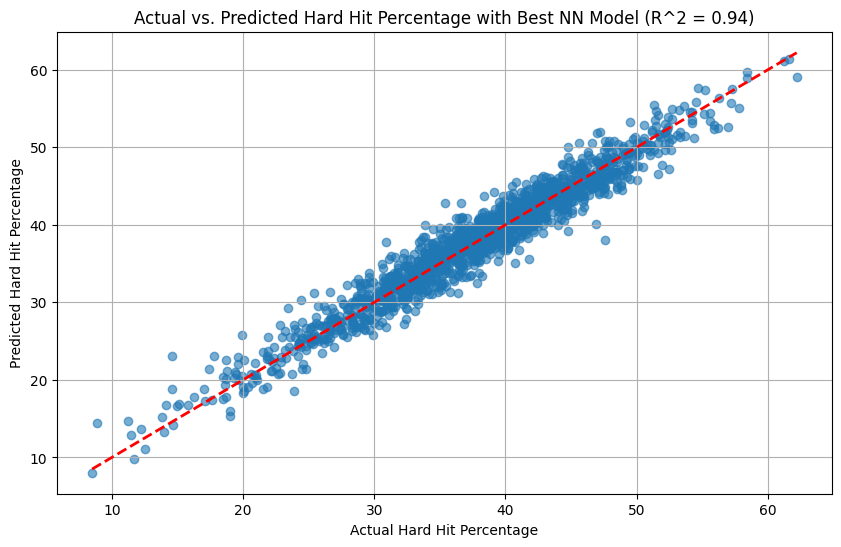

In [ ]:
import matplotlib.pyplot as plt

# 1. Select the best hyperparameters
best_hyperparams = results_df.loc[results_df['r2_mean'].idxmax()]
best_hidden_dim = int(best_hyperparams['hidden_dim'])
best_lr = best_hyperparams['lr']

print(f"Best Hyperparameters: hidden_dim={best_hidden_dim}, lr={best_lr}")

# 2. Define a function to train the final model on the full dataset
def train_final_model(
    X_np,
    y_np,
    hidden_dim,
    lr,
    batch_size=64,
    num_epochs=50,
    verbose=False
):
    """
    Train a final MLP on the entire dataset.
    Returns the trained model.
    """
    y_np = np.asarray(y_np)

    # Reset torch random seed for reproducibility
    torch.manual_seed(SEED)

    # Convert numpy arrays to PyTorch tensors
    X_t = torch.from_numpy(X_np).float()
    y_t = torch.from_numpy(y_np.reshape(-1, 1)).float()

    # Dataloader for mini-batch training
    dataset = TensorDataset(X_t, y_t)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    # Build model
    input_dim = X_np.shape[1]
    model = MLPRegressor(input_dim, hidden_dim=hidden_dim)

    # Loss + optimizer
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    # ----- Training loop -----
    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0.0

        for xb, yb in dataloader:
            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * xb.size(0)

        epoch_loss /= len(dataloader.dataset)

        if verbose and (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{num_epochs} - Train MSE: {epoch_loss:.4f}")
    return model

# 3. Preprocess the entire dataset
final_preprocessor = make_preprocessor()
X_processed = final_preprocessor.fit_transform(X)

# 4. Train the final model
print("\nTraining final model...")
final_model = train_final_model(
    X_processed,
    y,
    hidden_dim=best_hidden_dim,
    lr=best_lr,
    batch_size=64,
    num_epochs=50,
    verbose=True # Set to True to see training progress
)

# 5. Make predictions
final_model.eval()
with torch.no_grad():
    y_pred = final_model(torch.from_numpy(X_processed).float()).cpu().numpy().flatten()

# 6. Create visualizations
mse_final = mean_squared_error(y, y_pred)
r2_final = r2_score(y, y_pred)
print(f"\nFinal Model Performance on full dataset: MSE = {mse_final:.4f}, R^2 = {r2_final:.4f}")

plt.figure(figsize=(10, 6))
plt.scatter(y, y_pred, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2) # Line for perfect prediction
plt.xlabel("Actual Hard Hit Percentage")
plt.ylabel("Predicted Hard Hit Percentage")
plt.title(f"Actual vs. Predicted Hard Hit Percentage with Best NN Model (R^2 = {r2_final:.2f})")
plt.grid(True)
plt.show()